# Week 1 – Foundations of Digital Signal Processing - B


## Overview
This milestone focuses on the fundamentals of signal processing. You will explore the concepts of discrete and continuous signals, learn about Linear Time-Invariant (LTI) systems, and understand how convolution works both manually and through code. 
You'll also visualize basic signal types using NumPy and Matplotlib.

In this notebook, we will:
- Understand discrete vs. continuous signals
- Explore LTI systems, impulse & step response
- Perform convolution manually and using code
- Visualize basic signal types with NumPy/Matplotlib



## 1. Discrete vs. Continuous Signals

A **continuous signal** is defined at every point in time, typically as a function of a continuous variable such as time \( t \). For example, a sine wave \( \sin(t) \) is continuous because it can take any value at any point in time.

A **discrete signal**, on the other hand, is defined only at discrete points in time. It is often represented by a sequence of values, each corresponding to a specific point in time. Discrete signals are typically sampled from a continuous signal.

### Example: Continuous vs. Discrete Sine Wave
We can visualize the difference between a continuous and a discrete sine wave using NumPy and Matplotlib:




## Initialization

Run the following shell script to setup the environment for running the python code.


In [ ]:
!pip install numpy matplotlib scipy


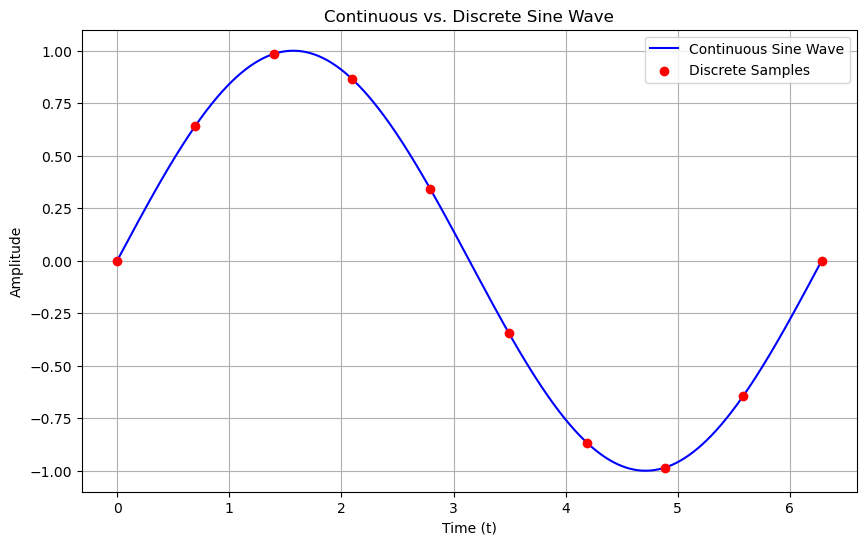

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Generate time axis for continuous signal
t_continuous = np.linspace(0, 2*np.pi, 1000)

# Continuous sine wave
y_continuous = np.sin(t_continuous)

# Generate time axis for discrete signal
t_discrete = np.linspace(0, 2*np.pi, 10)

# Discrete sine wave (sampled from continuous signal)
y_discrete = np.sin(t_discrete)

# Plotting both signals
plt.figure(figsize=(10, 6))
plt.plot(t_continuous, y_continuous, label='Continuous Sine Wave', color='blue')
plt.scatter(t_discrete, y_discrete, color='red', zorder=5, label='Discrete Samples')
plt.title('Continuous vs. Discrete Sine Wave')
plt.xlabel('Time (t)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()



## 2. LTI Systems, Impulse & Step Response

A **Linear Time-Invariant (LTI) system** is a system that satisfies two properties:
- **Linearity**: The system obeys the principle of superposition, meaning the response to a weighted sum of inputs is the weighted sum of the responses to each input.
- **Time-Invariance**: The system's behavior does not change over time.

An important concept in LTI systems is the **impulse response**. The impulse response \( h(t) \) describes the system's output when the input is a Dirac delta function \( \delta(t) \). The **step response** describes the system's output when the input is a unit step function.

We will now compute and visualize the impulse and step responses of a simple LTI system using NumPy.



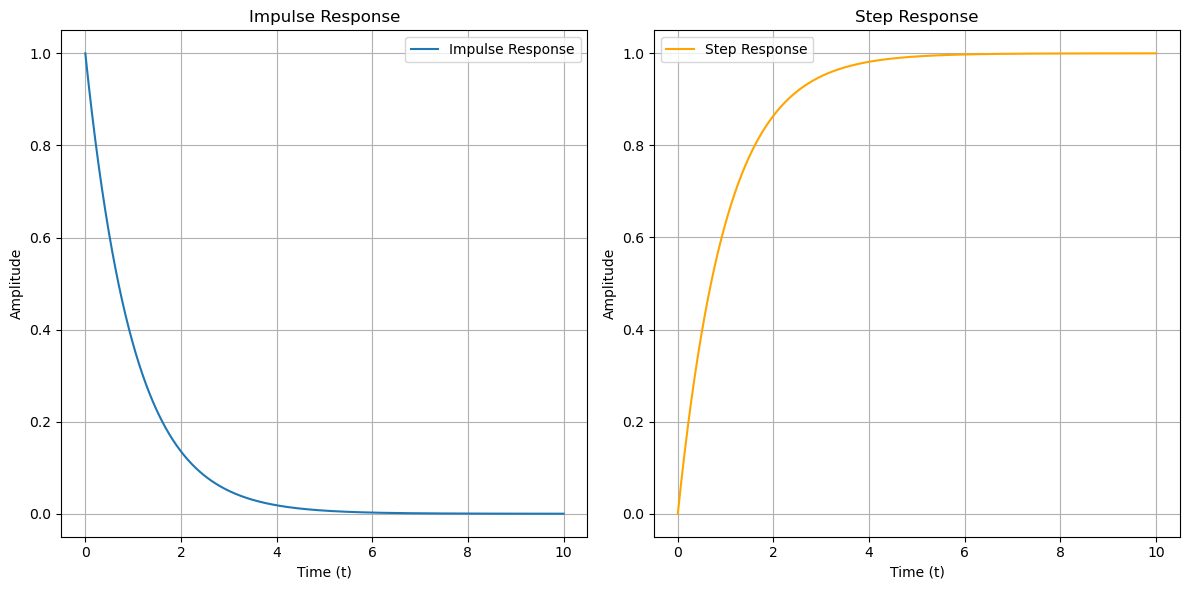

In [12]:

from scipy.signal import lti, step, impulse

# Define an LTI system (first-order system: h(t) = e^(-t))
num = [1]  # Numerator coefficients
den = [1, 1]  # Denominator coefficients

# Create LTI system
system = lti(num, den)

# Compute impulse and step responses
t = np.linspace(0, 10, 1000)
t_impulse, y_impulse = impulse(system, T=t)
t_step, y_step = step(system, T=t)

# Plot impulse and step response
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(t_impulse, y_impulse, label='Impulse Response')
plt.title('Impulse Response')
plt.xlabel('Time (t)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(t_step, y_step, label='Step Response', color='orange')
plt.title('Step Response')
plt.xlabel('Time (t)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



## 3. Convolution: Manually and Using Code

**Convolution** is a mathematical operation that expresses the way in which a system responds to a given input. For discrete signals, the convolution of two signals \( x(t) \) and \( h(t) \) is given by:

\[	ext{y}(t) = \int_{-\infty}^{\infty} x(	au) h(t-	au) d	au\]

In the discrete case, it becomes a sum:

\[	ext{y}[n] = \sum_{m=-\infty}^{\infty} x[m] h[n-m]\]

We will now manually perform convolution and also use NumPy to compute the convolution.



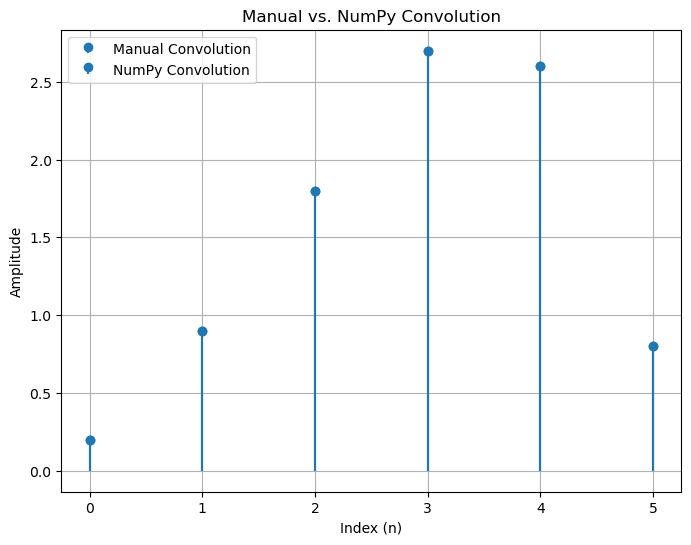

In [15]:

# Define two signals for convolution
x = np.array([1, 2, 3, 4])
h = np.array([0.2, 0.5, 0.2])

# Manually compute convolution (discrete)
y_manual = np.convolve(x, h, mode='full')

# Compute convolution using NumPy's convolve function
y_numpy = np.convolve(x, h, mode='full')

# Plot both
plt.figure(figsize=(8, 6))
plt.stem(range(len(y_manual)), y_manual, label='Manual Convolution', basefmt=" ")
plt.stem(range(len(y_numpy)), y_numpy, label='NumPy Convolution', markerfmt="o", basefmt=" ")
plt.title('Manual vs. NumPy Convolution')
plt.xlabel('Index (n)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()



## 4. Visualize Basic Signal Types with NumPy/Matplotlib

In this section, we will visualize some basic signal types using NumPy and Matplotlib. These include:
- **Sine wave**: A continuous periodic signal
- **Square wave**: A periodic signal that alternates between two values
- **Sawtooth wave**: A periodic waveform that rises linearly and then drops

We will use NumPy to generate these signals and visualize them with Matplotlib.



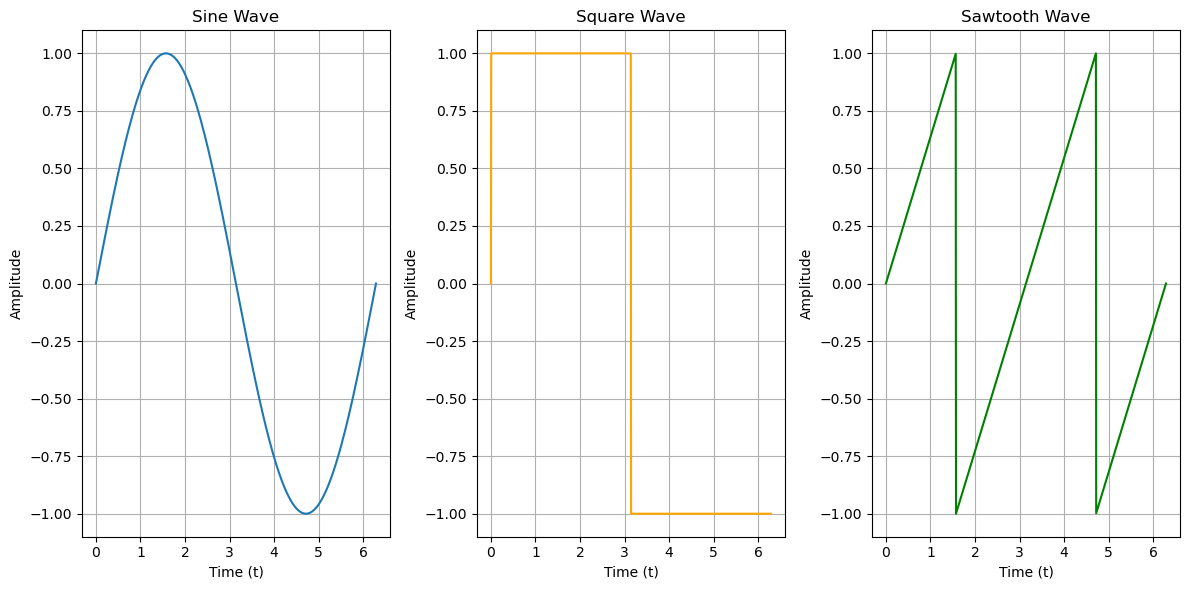

In [16]:

# Generate time axis for signals
t = np.linspace(0, 2*np.pi, 1000)

# Generate different signals
sine_wave = np.sin(t)
square_wave = np.sign(np.sin(t))
sawtooth_wave = 2*(t/np.pi - np.floor(t/np.pi + 0.5))

# Plot all signals
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.plot(t, sine_wave, label='Sine Wave')
plt.title('Sine Wave')
plt.xlabel('Time (t)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(t, square_wave, label='Square Wave', color='orange')
plt.title('Square Wave')
plt.xlabel('Time (t)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(t, sawtooth_wave, label='Sawtooth Wave', color='green')
plt.title('Sawtooth Wave')
plt.xlabel('Time (t)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()
